# Dataset Exploration for Named Entity Recognition (IOB2)

Before building any models, I analyse the CoNLL-2003 dataset to understand its structural and statistical properties.


Specifically, I examine:

- **Label imbalance: The "O" Problem**   
    How dominant is the "O" class compared to entity labels? This affects evaluation metrics and model bias.

- **Sentence length distribution**    
    Are the sentences mostly long news articles or short fragments? This informs padding strategy and maximum sequence length for the BiLSTM.
    
- **Surface cues**  
    Do entities typically start with capital letters or contain specific character patterns? These signals guide feature engineering for the Logistic Regression baseline.

- **Multi-token entity spans**  
    How often do we observe multi-token entities? This helps estimate the importance of sequence modelling.
    
- **Vocabulary coverage and OOV (Out-of-Vocabulary) issues**  
    How large is the vocabulary, and how often do unseen words appear in validation/test splits? This informs embedding and generalisation strategies.

## Objective

The goal is to derive modelling hypotheses that will inform:

- Feature design for the Logistic Regression baseline
- Architectural choices for the BiLSTM sequence model

This notebook follows a data-first, hypothesis-driven approach.

In [ ]:
%cd /content/drive/MyDrive/projects/ner-comparison-project/

/content/drive/MyDrive/projects/ner-comparison-project


In [ ]:
# Creating the folders in Repository Structure
import os

folders = ["data/raw", "data/processed", "src", "models", "results", "notebooks"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

Download the CoNLL003 (English-version) dataset

In [ ]:
# Create kaggle connection
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efemirkan","key":"374cc44929371121bc09ffedd7711d89"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the CoNLL003 (English-version) dataset
!kaggle datasets download -d alaakhaled/conll003-englishversion -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/alaakhaled/conll003-englishversion
License(s): CC0-1.0
  0% 0.00/960k [00:00<?, ?B/s]
100% 960k/960k [00:00<00:00, 56.3MB/s]


### **1- Load the Dataset**

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.load_dataset import load_dataset

train_sents, train_tags = load_dataset("../data/raw/train.txt")
valid_sents, valid_tags = load_dataset("../data/raw/valid.txt")
test_sents, test_tags = load_dataset("../data/raw/test.txt")

In [3]:
print(f"Training sentences: {len(train_sents)}")
print(f"Testing tags: {len(test_tags)}")

Training sentences: 14041
Testing tags: 3453


In [4]:
print(train_sents[:5])
print(valid_tags[:5])
print(test_sents[:5])

[['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], ['Peter', 'Blackburn'], ['BRUSSELS', '1996-08-22'], ['The', 'European', 'Commission', 'said', 'on', 'Thursday', 'it', 'disagreed', 'with', 'German', 'advice', 'to', 'consumers', 'to', 'shun', 'British', 'lamb', 'until', 'scientists', 'determine', 'whether', 'mad', 'cow', 'disease', 'can', 'be', 'transmitted', 'to', 'sheep', '.'], ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']]
[['O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'], ['B-LOC', 'O'], ['B-MISC', 'I-MISC', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'],

In [5]:
# Sanity Check
for s, t in zip(train_sents[:10], train_tags[:10]):
    assert len(s) == len(t)
print(f"Words and tags matched")

Words and tags matched


I can confirm that datasets align accurately.

### **2- Basic Statistics**

- **How big is the dataset?** Dataset size affects model capacity.
- **How long are the sentences?** Sentence length affect padding strategy.
- **Is the data structually consistent? Are tokens aligned with tags?** Misalignent bugs destroy training step.


In [6]:
from src.basic_stats import dataset_stats, sent_length_distribution, check_sanity

In [7]:
print("Training Set Stats:")
dataset_stats(train_sents, train_tags)
print("-")
print("Validation Set Stats:")
dataset_stats(valid_sents, valid_tags)
print("-")
print("Test Set Stats:")
dataset_stats(test_sents, test_tags)

Training Set Stats:
Number of sentences: 14041
Number of tokens: 203621
Number of tags: 203621
Average sentence length: 14.50
-
Validation Set Stats:
Number of sentences: 3250
Number of tokens: 51362
Number of tags: 51362
Average sentence length: 15.80
-
Test Set Stats:
Number of sentences: 3453
Number of tokens: 46435
Number of tags: 46435
Average sentence length: 13.45


I have ~14k sentences and ~200k tokens in the training set. This means the model is exposed to many labeled entity instances as well as diverse surrounding word contexts, allowing it to learn both what entities look like and when they occur. Therefore, the dataset is large enough for a BiLSTM to learn meaningful patterns. At the same time, ~200k tokens per epoch is relatively small, so the model can train quickly.

The average sentence length is 13-16 tokens. Since the computational cost of an LSTM gros with sequence length, shorter sentences require less memory and computation. This results in faster training and efficient batching. Therefore, the dataset is friendly for sequence models such as BiLSTM.

The training, validation and test sets have similar average sentence lengths. This suggests that there is no major distribution shift between splits. Thus, evaluation results on the validation and test sets are likely to reflect true model generalisation.

In [8]:
print(f"Avg. sentence length statistics in training set:")
sent_length_distribution(train_sents)
print("-")
print(f"Avg. sentence length statistics in validation set:")
sent_length_distribution(valid_sents)
print("-")
print(f"Avg. sentence length statistics in testing set:")
sent_length_distribution(test_sents)

Avg. sentence length statistics in training set:
Mean length: 14.50
Median length: 10.0
95th percentile: 37.0
Max length: 113
-
Avg. sentence length statistics in validation set:
Mean length: 15.80
Median length: 11.0
95th percentile: 39.0
Max length: 109
-
Avg. sentence length statistics in testing set:
Mean length: 13.45
Median length: 9.0
95th percentile: 37.0
Max length: 124


The median sentence length is 9-11 tokens, incdicating that most sentences are relatively short. However, the mean sentence length is higher (around 13–16 tokens), which suggests a **right-skewed distribution** where a small number of longer sentences increase the average.

The 95th percentile is around 37-39 token, suggesting that long sentence are rare, only last 5% exceed these lengths.

Although the maximum sentence length exceeds 100 tokens, these cases are outliers.

THerefore, I will choose to use **dynamic padding** for the BiLSTM model. Since most sentences are relatively short and only a small number are significantly longer, dynamic padding allows each batch to be padded only to the maximum length within that batch, avoiding unnecessary computation. This is more efficient than using a fixed maximum sequence length, while still preserving all input information.

In [9]:
print("In Training set")
check_sanity(train_sents, train_tags)
print("-")
print("In Validation set")
check_sanity(valid_sents, valid_tags)
print("-")
print("In Testing set")
check_sanity(test_sents, test_tags)

In Training set
Tokens and tags matched
-
In Validation set
Tokens and tags matched
-
In Testing set
Tokens and tags matched


Token and label alignment checks passed for all sets. This confirms that each token is associated with exactly one tag.

Therefore, the dataset is consistent and safe for sequence modelling.

### **3- Tag Distribution**

In [10]:
# Reload basic_stats.py
import importlib, src.basic_stats
importlib.reload(src.basic_stats)

<module 'src.basic_stats' from 'd:\\AI\\repos\\ner-comparison-project\\src\\basic_stats.py'>

In [11]:
from src.basic_stats import tag_distribution

train_tag_counts, train_tag_count_perc = tag_distribution(train_tags)
valid_tag_counts, valid_tag_count_perc = tag_distribution(valid_tags)
test_tag_counts, test_tag_count_perc = tag_distribution(test_tags)

In [12]:
print("Training set tag distribution by percentage")
print(train_tag_count_perc)
print("-")
print("Validation set tag distribution by percentage")
print(valid_tag_count_perc)
print("-")
print("Testing set tag distribution by percentage")
print(test_tag_count_perc)

Training set tag distribution by percentage
{'B-LOC': 3.51, 'B-MISC': 1.69, 'B-ORG': 3.1, 'B-PER': 3.24, 'I-LOC': 0.57, 'I-MISC': 0.57, 'I-ORG': 1.82, 'I-PER': 2.22, 'O': 83.28}
-
Validation set tag distribution by percentage
{'B-LOC': 3.58, 'B-MISC': 1.8, 'B-ORG': 2.61, 'B-PER': 3.59, 'I-LOC': 0.5, 'I-MISC': 0.67, 'I-ORG': 1.46, 'I-PER': 2.54, 'O': 83.25}
-
Testing set tag distribution by percentage
{'B-LOC': 3.59, 'B-MISC': 1.51, 'B-ORG': 3.58, 'B-PER': 3.48, 'I-LOC': 0.55, 'I-MISC': 0.47, 'I-ORG': 1.8, 'I-PER': 2.49, 'O': 82.53}


<Axes: >

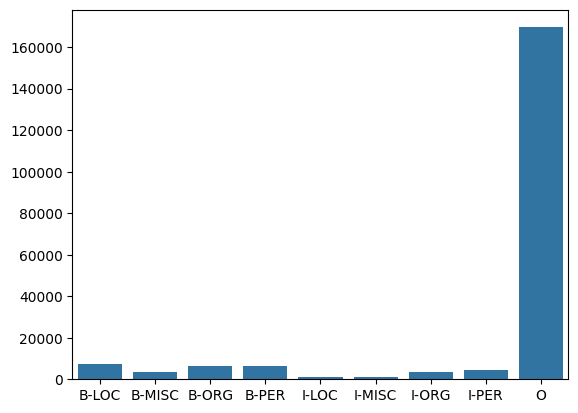

In [13]:
import seaborn as sns


sns.barplot(train_tag_counts, x=list(train_tag_counts.keys()), y=list(train_tag_counts.values()))

Text(0.5, 1.0, 'Train, Valid, Test Datasets Tag Distributions')

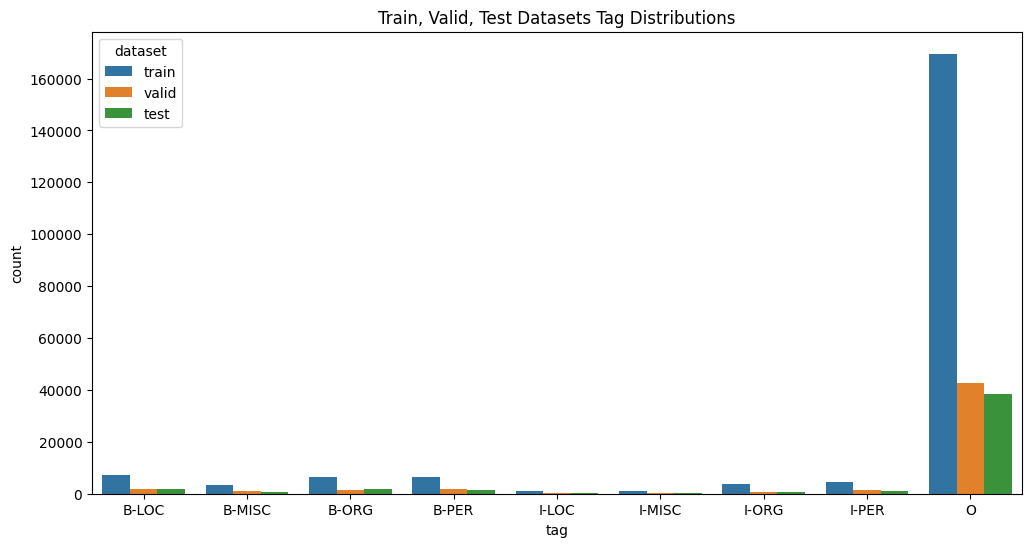

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert counters to DataFrames
train_tag_df = pd.DataFrame({"tag": train_tag_counts.keys(), "count": train_tag_counts.values(), "dataset": "train"})

valid_tag_df = pd.DataFrame({"tag": valid_tag_counts.keys(), "count": valid_tag_counts.values(), "dataset": "valid"})

test_tag_df = pd.DataFrame({"tag": test_tag_counts.keys(), "count": test_tag_counts.values(), "dataset": "test"})

# Merge all
all_tag_df = pd.concat([train_tag_df, valid_tag_df, test_tag_df])

plt.figure(figsize=(12,6))
sns.barplot(all_tag_df, x="tag", y="count",hue="dataset")
plt.title("Train, Valid, Test Datasets Tag Distributions")

Text(0.5, 1.0, "Train, Valid, Test Datasets Tag Distributions without 'O'")

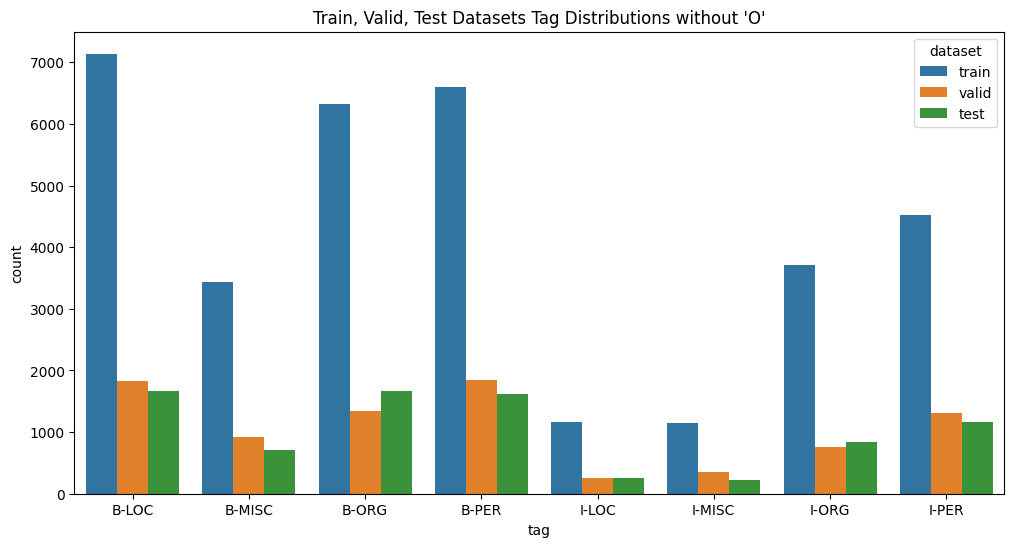

In [15]:
# Plot without "O"
removed_o_df = all_tag_df[all_tag_df["tag"] != "O"]

plt.figure(figsize=(12,6))
sns.barplot(removed_o_df, x="tag", y="count",hue="dataset")
plt.title("Train, Valid, Test Datasets Tag Distributions without 'O'")

I observe that the dataset splits exhibits strong class imbalance, with the "O" tag representing around 82-83% of all tokens. This makes token level accuracy misleading and motivates me to use of entity level F1 as the primary evaluation metric.

I also observe that the tag distributions is high consistent across training, validation and test sets, indicating no significant distribution shift.

Furthermore, I notice that B-tags are generally more frequent than I-tags, suggesting that many entities consist of single token. Additionally, the MISC category appears less frequent then PER, ORG and LOC which may affect per class performance.

### **4- Entity Distribution**

In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 404 bytes | 4.00 KiB/s, done.
From https://github.com//Efemirkan/ner-comparison-project
   3107c98..3caeeef  main       -> origin/main
Updating 3107c98..3caeeef
Fast-forward
 src/basic_stats.py | 3 +++
 1 file changed, 3 insertions(+)


In [16]:
from itertools import zip_longest
from src.basic_stats import entity_distribution

train_entity_counts, train_no_o_counts = entity_distribution(train_tags)
valid_entity_counts, valid_no_o_counts = entity_distribution(valid_tags)
test_entity_counts, test_no_o_counts = entity_distribution(test_tags)

In [17]:
cols = pd.MultiIndex.from_product([['Counts'], ["Training Set", "Validation Set", "Testing Set"]])

df_entity = pd.DataFrame(list(zip_longest(train_entity_counts.values(), valid_entity_counts.values(), test_entity_counts.values())),
                         columns=cols, index=train_entity_counts.keys())



df_entity

Counts                           
     Training Set Validation Set Testing Set
LOC          8297           2094        1925
MISC         4593           1268         918
O          169578          42759       38323
ORG         10025           2092        2496
PER         11128           3149        2773

Text(0.5, 1.0, "Train, Valid, Test Datasets Entity Distributions without 'O'")

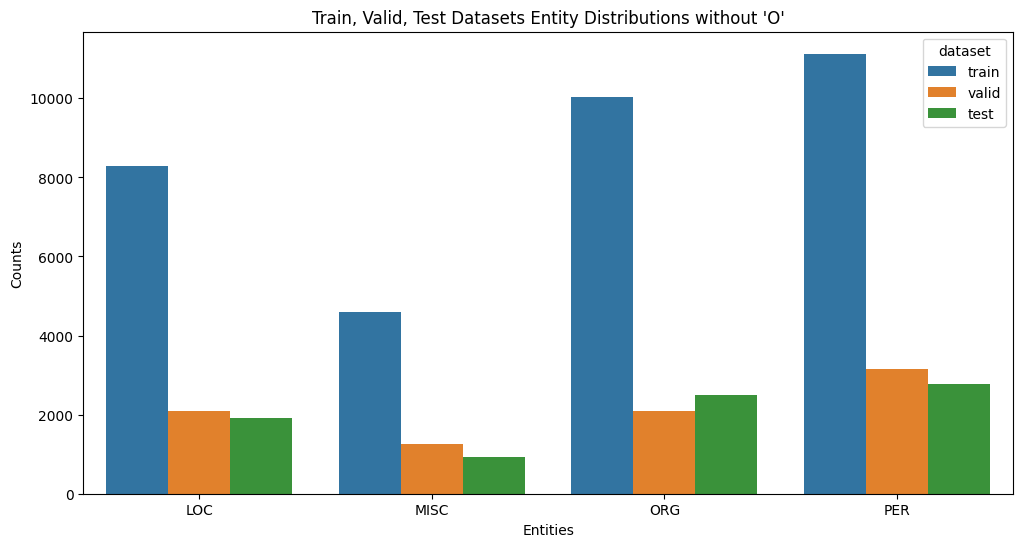

In [18]:
# Convert counters to DataFrames
train_entity_df = pd.DataFrame({"entity": train_no_o_counts.keys(), "count": train_no_o_counts.values(), "dataset": "train"})

valid_entity_df = pd.DataFrame({"entity": valid_no_o_counts.keys(), "count": valid_no_o_counts.values(), "dataset": "valid"})

test_entity_df = pd.DataFrame({"entity": test_no_o_counts.keys(), "count": test_no_o_counts.values(), "dataset": "test"})

# Merge all
all_entity_df = pd.concat([train_entity_df, valid_entity_df, test_entity_df])

plt.figure(figsize=(12,6))
sns.barplot(all_entity_df, x="entity", y="count",hue="dataset")
plt.xlabel("Entities")
plt.ylabel("Counts")
plt.title("Train, Valid, Test Datasets Entity Distributions without 'O'")

After collapsing the BIO tags into entity types, I observe that PER is the most frequent entity class, followed closely by ORG and LOC, while MISC is the least frequent across all splits. The relative distribution of entity types is very similar between the training, validation, and test sets, which suggests that there is no significant distribution shift in terms of entity categories.

Although the dataset is highly imbalanced at the token level due to the dominance of the O tag, the distribution among the actual entity types is relatively balanced.

### **4- Surface Cues**

I design token-level features based on observable surface patterns such as capitalisation, punctuation, and suffixes. 

These features aim to capture simple but informative signals that distinguish entity tokens from non-entity tokens. 

* **is_capitalised** : Many named entities are capitalised.
* **is_all_caps** : Strong signal for ORG, aiming to capture abbreviations.
* **has_digit** : PER does not contain digits, while it is common for ORG and MISC
* **has_hyphen** : Appears in ORG and MISC
* **is_title_case** : Strong signal for PER or LOC
* **has_punctuation** : Appears in ORG and MISC
* **has_suffix** : To capture morphological patterns such as -ton, -burg for LOC, -inc, -ltd for ORG.

I separate has_hyphen from has_punctuation because hyphens represent a specific structural pattern that may be associated with certain entity types, while general punctuation captures a broader set of patterns. Keeping them separate allows the model to learn more precise distinctions instead of treating all punctuation the same.

These surface cues are particularly important for the Logistic Regression baseline, which relies entirely on manually engineered features rather than learned representations.

In [19]:
from src.surface_cues import build_surface_df

In [20]:
surface_df = build_surface_df(train_sents, train_tags)
surface_df

,token,tag,entity_type,is_entity,is_capitalised,is_all_caps,has_digit,has_hyphen,is_title_case,has_punctuation,has_suffix
0,EU,B-ORG,ORG,1,1,1,0,0,0,0,eu
1,rejects,O,O,0,0,0,0,0,0,0,cts
2,German,B-MISC,MISC,1,1,0,0,0,1,0,man
3,call,O,O,0,0,0,0,0,0,0,all
4,to,O,O,0,0,0,0,0,0,0,to
...,...,...,...,...,...,...,...,...,...,...,...
203616,three,O,O,0,0,0,0,0,0,0,ree
203617,Swansea,B-ORG,ORG,1,1,0,0,0,1,0,sea
203618,1,O,O,0,0,0,1,0,0,0,1
203619,Lincoln,B-ORG,ORG,1,1,0,0,0,1,0,oln


Group by **entity_type** to visualize surface patterns

In [21]:
surface_summary = surface_df.groupby('entity_type')[

    ['is_capitalised', 'is_all_caps', 'has_digit', 'has_hyphen', 'is_title_case', 'has_punctuation']

    ].mean().round(3) * 100

surface_summary

,is_capitalised,is_all_caps,has_digit,has_hyphen,is_title_case,has_punctuation
entity_type,,,,,,
LOC,99.4,21.1,0.0,0.4,82.4,4.9
MISC,96.0,17.8,2.2,4.3,78.1,7.7
O,6.8,2.0,11.2,3.5,5.3,21.1
ORG,96.2,19.0,0.2,0.7,77.9,3.4
PER,99.3,3.7,0.0,0.8,97.3,3.8


Most entity tokens are capitalised far more often than non-entity tokens, which is exactly what I would expect here. Casing is likely to be a strong signal for named entity recognition, especially for a feature-based model.

Non-entity tokens **O** are rarely capitalised and contain **more punctuation**, which helps separate them from entity tokens. 

I also notice some differences between entity types. PER tokens are mostly in title case, which reflects person names, while ORG tokens have a higher proportion of uppercase forms, likely due to abbreviations such as "E.U." or "U.N.". MISC tokens show more variation, including digits and hyphens, which makes them less consistent.

Overall, these patterns confirm that surface-level features such as casing, punctuation, and token shape are informative and should be included in the Logistic Regression baseline.

Group by **entity_type** to visualize suffix patterns

In [22]:
from collections import Counter

# To discover suffix patterns
suffix_summary = (surface_df[surface_df['entity_type'] != 'O'].groupby('entity_type')['has_suffix'].agg(lambda x: Counter(x).most_common(5)))

suffix_summary

entity_type
LOC     [(and, 390), (.s., 309), (ain, 249), (new, 168...
MISC    [(ian, 562), (ish, 298), (can, 162), (cup, 120...
ORG     [(ion, 251), (ers, 174), (and, 151), (ton, 147...
PER     [(son, 211), (ton, 175), (man, 138), (ter, 99)...
Name: has_suffix, dtype: object

The suffix analysis shows that certain endings appear more frequently within specific entity types. While these suffixes do not fully explain the structure of entities, they provide useful hints about common patterns in names and locations.

For example, some suffixes are more common in person names, while others may appear more often in locations or organisations. Although suffix features are relatively simple, they can still help the model capture basic morphological patterns.



### **5- Entity Span Analysis**

I aim to evaluate NER performance at the entity level instead of token level with entity span analysis.

In NER, predicting individual tokens correctly is not enough. The key point is whether the model can:

* capture the full entity
* keep the correct boundaries
* assign the correct label.

To support this, I analyse entity spans using:

* 'entity_type' to identify the category and compare across types.
* 'span_text' to capture the entity and check how often it appears. Rare vs. Frequent
* 'span_length' to measure entity length and see if longer ones are harder. Boundary issues.

In [23]:
from src.entity_span import extract_entity_spans

In [24]:
entity_span_df = extract_entity_spans(train_sents, train_tags)
entity_span_df

,entity_type,span_text,span_length
0,ORG,EU,1
1,MISC,German,1
2,MISC,British,1
3,PER,Peter Blackburn,2
4,LOC,BRUSSELS,1
...,...,...,...
23494,MISC,English,1
23495,ORG,Plymouth,1
23496,ORG,Preston,1
23497,ORG,Swansea,1


In [25]:
span_length_counts = (entity_span_df['span_length']
                                                .value_counts()
                                                .sort_index()
                                                .to_frame('count')
                                            )

span_length_counts

,count
span_length,
1,14831
2,7384
3,904
4,250
5,82
6,25
7,18
8,2
10,3


From the results, I can see that most entities are very short. This shows that the dataset is dominated by single-token entities, and then some two-token entities.

This means models will perform well on short spans, but may struggle with longer and more complex entities due to limited examples.

Explore basic statistic in entity_span_df

In [26]:
# Groupby 'entity_type' by computing 'span_length' 

span_stats = entity_span_df.groupby('entity_type')['span_length'].agg(['count', 'mean', 'median', 'max']).round(2)
span_stats

,count,mean,median,max
entity_type,,,,
LOC,7140,1.16,1.0,10
MISC,3438,1.34,1.0,7
ORG,6321,1.59,1.0,10
PER,6600,1.69,2.0,6


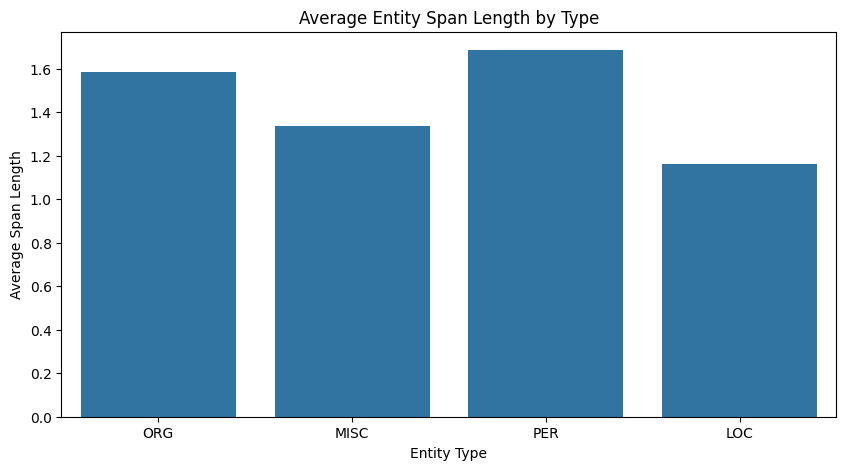

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=entity_span_df, x='entity_type', y='span_length', estimator='mean', errorbar=None)
plt.title('Average Entity Span Length by Type')
plt.xlabel('Entity Type')
plt.ylabel('Average Span Length')
plt.show()

From the results, I observe that most entities have length = 1, which indicates that the dataset is mainly composed of single-token entities. 

Also, PER has a median length of 2, which suggests that person names are often multi-word such as first name and surname. In addition, ORG and LOC can have longer spans up to 10 tokens, which indicates the presence of more complex entity structures.

From the plot, ORG and PER have higher average span lengths, while LOC is generally shorter.

Overall, I understand that although most entities are short, some types, especially ORG and LOC, include longer spans. This suggests that models may struggle more with these entity types, since longer entities are more likely to be partially predicted or broken.

Compute **rare entities**

In [28]:
# Find out how many times appears same 'span_text' in entity_span_df
rare_entity_counts = entity_span_df['span_text'].value_counts()

# Create filter for the entities appears smaller than 5 times
rare_entities = rare_entity_counts[rare_entity_counts < 5]

# Filter out rare entities in 'entity_span_df' and groupby with 'entity_type'
rare_entity_by_type = (entity_span_df[entity_span_df['span_text'].isin(rare_entities.index)]
                                                                                            .groupby('entity_type')
                                                                                            .size() # return number of rare entity spans per type
                                                                                            .sort_values(ascending=False)
                                                                                            .to_frame('rare_entity_spans') # Convert to Dataframe, size() series
                                                                                            )

rare_entity_by_type

,rare_entity_spans
entity_type,
PER,4911
ORG,3247
LOC,1556
MISC,1043


I perform this analysis to understand the data sparsity problem in the dataset. This is important because models usually learn frequent patterns better, but struggle with rare ones.

From the results, I observe that PER has the highest number of rare entities, followed by ORG, while LOC and MISC have fewer rare entities. This suggests that person names are highly diverse, so many of them appear only a few times. Similarly, organisation names also show high variability. In contrast, location names are more repeated, which results in lower sparsity.

I also notice that a large proportion of entities, especially in PER and ORG categories, are low-frequency. This indicates a strong data sparsity issue in the dataset.
The model may struggle more with PER and ORG entities, since it has limited exposure to many of these entity patterns during training.

These findings provide a basis for interpreting the model results, where I expect **boundary errors** for longer entities and lower performance on rare entities due to **data sparsity**.

### **6- Vocabulary Overlap and OOV Analysis**

##### 6.1 Vocabulary Overlap

I aim to find out how much of the validation/test vocabulary is already seen in the training set by vocabulary overlap measure. BEcause, if overlap is high, model sees familiar words,so easier task; if overlap is low, many unseen words, so harder task.

In [36]:
from src.overlap_oov import token_level, token_oov_df

In [37]:
# Convert sets so that vocabs consist of unique words 
train_vocab = set(token_level(train_sents))
valid_vocab = set(token_level(valid_sents))
test_vocab = set(token_level(test_sents))

In [38]:
overlap_df = pd.DataFrame({
                            'split': ['valid', 'test'],
                            'vocab_size': [len(valid_vocab), len(test_vocab)],
                            'seen_in_train': [len(valid_vocab & train_vocab), len(test_vocab & train_vocab)],
                            'unseen_in_train': [len(valid_vocab - train_vocab), len(test_vocab - train_vocab)]
                        })

overlap_df

,split,vocab_size,seen_in_train,unseen_in_train
0,valid,9966,6706,3260
1,test,9488,5795,3693


In [39]:
# Add columns to find percentage of overlap and OOV
overlap_df['overlap_rate_perc'] = (100 * overlap_df['seen_in_train'] / overlap_df['vocab_size']).round(2)
overlap_df['oov_vocab_rate_perc'] = (100 * overlap_df['unseen_in_train'] / overlap_df['vocab_size']).round(2)
overlap_df

,split,vocab_size,seen_in_train,unseen_in_train,overlap_rate_perc,oov_vocab_rate_perc
0,valid,9966,6706,3260,67.29,32.71
1,test,9488,5795,3693,61.08,38.92


For the validation set, there are 9966 unique tokens, and 6706 of them are seen in the training data and 3,260 tokens are unseen. For the test set, the situation is slightly harder. Out of 9488 tokens, only 5795 are seen, while 3693 are unseen.

From this, I can see that the overlap is moderate, not very high. This means the model will face a noticeable number of unseen words, especially in the test set. The proportion of unseen words is higher in the test set %38.92, which makes it slightly more challenging for the model.

Overall, this suggests that the task is not trivial, because the model cannot rely only on memorising words from training. It needs to generalise to new tokens. This is especially important for NER, where many entities are rare or appear only once.

This also supports my expectation that the feature-based model may struggle more with unseen words, while the BiLSTM model may handle them better using context.


##### 6.2 OOV Analysis

I will use OOV analysis to understand how often the model sees unseen tokens, especially under data sparsity where rare entities are more common.

In [41]:
# Create OOV dataframe for both valid set and test set
valid_oov_df = token_oov_df(valid_sents, valid_tags, train_vocab, 'valid')
test_oov_df = token_oov_df(test_sents, test_tags, train_vocab, 'test')

In [42]:
# Concatenate both data frame 
combined_oov_df = pd.concat([valid_oov_df, test_oov_df], ignore_index=True)
combined_oov_df

,token,tag,entity_type,is_oov,split
0,CRICKET,O,O,0,valid
1,-,O,O,0,valid
2,LEICESTERSHIRE,B-ORG,ORG,1,valid
3,TAKE,O,O,0,valid
4,OVER,O,O,0,valid
...,...,...,...,...,...
97792,younger,O,O,0,test
97793,brother,O,O,0,test
97794,",",O,O,0,test
97795,Bobby,B-PER,PER,0,test


In [49]:
# Groupby combined_oov_df split and compute mean of the OOV words percentage in both split
overall_oov = (combined_oov_df.groupby('split')['is_oov'].mean().round(4) * 100).to_frame('overall_oov_rate_perc')
overall_oov

,overall_oov_rate_perc
split,
test,12.18
valid,8.36


In [58]:
# Group by with entity type that is not O and compute mean of the OOV words percentage for each entity in both split
per_entity_oov = (combined_oov_df[combined_oov_df['entity_type'] != 'O']
                                                                        .groupby(['split', 'entity_type'])['is_oov']
                                                                        .mean()
                                                                        .round(4)
                                                                        .mul(100)
                                                                        .reset_index()
                                                                        )
per_entity_oov

,split,entity_type,is_oov
0,test,LOC,14.03
1,test,MISC,20.37
2,test,ORG,23.32
3,test,PER,54.02
4,valid,LOC,10.51
5,valid,MISC,13.33
6,valid,ORG,15.82
7,valid,PER,32.80


First of all, when looking at the overall OOV rate, I can see that the test set 12.18% has a higher OOV rate than the validation set 8.36%. This means the test set is more challenging, as the model needs to deal with more unseen words.

When I look at the results by entity type, the difference becomes more clear. The PER category has the highest OOV rate in both splits, especially in the test set where it reaches 54.02%. This is very high, and it suggests that many person names are unseen during training. This is expected in NER, because new person names appear frequently and are often rare.

ORG also has relatively high OOV rates 23.32% in test, followed by MISC and LOC, which have lower values. This suggests that location names are more likely to be seen during training, while organisations and especially person names are more sparse.

Overall, this shows that data sparsity is not uniform across entity types. Some categories, especially PER, are much more affected by unseen tokens. Therefore, I expect lower performance on these entity types, especially for the feature-based model.

### **7- Hypothesis Before Modelling**

Based on the exploration above, I can form a few expectations before training either model:

1. The logistic regression baseline should benefit strongly from visible surface cues such as capital letters, punctuation patterns, and short suffixes.

2. The BiLSTM should cope better with unseen words, as it can use surrounding context rather than relying only on the token itself.

3. Rare entities and OOV entities are likely to affect the feature-based model more than the BiLSTM.

4. Longer entity spans, especially for ORG labels, may lead to more boundary errors, as the model needs to identify both the start and end correctly.

5. PER entities may be easier overall, as they often follow clearer capitalisation patterns in news text.